## Bitcoin Market Analysis from 2014-2026

This dataset comes from Yahoo Finance a using`yfinance'. It contains **daily** observations of Bitcoin's (BTC-USD) opening price, high, low, closing price, and trading volume going back to Yahoo Finance's earliest available date for BTC-USD (around September 2014).

Bitcoin is the largest cryptocurrency by market capitalization. Unlike stocks, it trades 24/7 and has no central exchange, which tends to make it more volatile than traditional assets like the S&P 500. Companies and funds who buy Bitcoin, investor sentiment, and macroeconomic conditions (interest rates, stock market performance, etc) are all commonly cited as drivers of its price.

## Has Bitcoin's price and volatility changed over time, and how closely does it move with the broader stock market (S&P 500)?

In [24]:
#Packages

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import statsmodels.api as sm 
import datetime as dt 
import yfinance as yf 

## 2. Analysis

In [25]:
btc = yf.Ticker('BTC-USD')
df = btc.history(period='max') 
df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2014-09-17 00:00:00+00:00,465.864014,468.174011,452.421997,457.334015,21056800,0.0,0.0
2014-09-18 00:00:00+00:00,456.859985,456.859985,413.104004,424.440002,34483200,0.0,0.0
2014-09-19 00:00:00+00:00,424.102997,427.834991,384.532013,394.795990,37919700,0.0,0.0
2014-09-20 00:00:00+00:00,394.673004,423.295990,389.882996,408.903992,36863600,0.0,0.0
2014-09-21 00:00:00+00:00,408.084991,412.425995,393.181000,398.821014,26580100,0.0,0.0
...,...,...,...,...,...,...,...
2026-07-11 00:00:00+00:00,64127.968750,64445.460938,63785.621094,63802.027344,13954689047,0.0,0.0
2026-07-12 00:00:00+00:00,63791.402344,64243.132812,63606.824219,63758.218750,19043437787,0.0,0.0
2026-07-13 00:00:00+00:00,63757.171875,64340.882812,61769.000000,62239.121094,37650044790,0.0,0.0


In [26]:
df = df.reset_index()

df.rename(columns={'Date': 'date', 'Open': 'open', 'High': 'high',
                    'Low': 'low', 'Close': 'close', 'Volume': 'volume'}, inplace=True)

df['date'] = df['date'].dt.tz_localize(None) 

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

df = df[['date', 'year', 'month', 'open', 'high', 'low', 'close', 'volume']]
df.head()

,date,year,month,open,high,low,close,volume
0,2014-09-17,2014,9,465.864014,468.174011,452.421997,457.334015,21056800
1,2014-09-18,2014,9,456.859985,456.859985,413.104004,424.440002,34483200
2,2014-09-19,2014,9,424.102997,427.834991,384.532013,394.795990,37919700
3,2014-09-20,2014,9,394.673004,423.295990,389.882996,408.903992,36863600
4,2014-09-21,2014,9,408.084991,412.425995,393.181000,398.821014,26580100


In [27]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
date      0
year      0
month     0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [28]:
df.describe().round(2)

,date,year,month,open,high,low,close,volume
count,4320,4320.00,4320.00,4320.00,4320.00,4320.00,4320.00,4.320000e+03
mean,2020-08-15 12:00:00,2020.12,6.50,28938.50,29507.78,28331.11,28952.40,2.235929e+10
min,2014-09-17 00:00:00,2014.00,1.00,176.90,211.73,171.51,178.10,5.914570e+06
25%,2017-08-31 18:00:00,2017.00,3.00,3508.83,3611.71,3447.35,3521.09,1.760800e+09
50%,2020-08-15 12:00:00,2020.00,6.00,11770.68,12003.00,11500.38,11781.96,1.816496e+10
75%,2023-07-31 06:00:00,2023.00,10.00,47266.86,48465.73,46424.62,47262.04,3.444413e+10
max,2026-07-15 00:00:00,2026.00,12.00,124752.14,126198.07,123196.05,124752.53,3.509679e+11
std,NaN,3.44,3.47,32456.30,32999.24,31868.73,32457.36,2.285730e+10


In [29]:
max_row = df.loc[df['close'].idxmax()]
print('Highest closing price on record:')
print(max_row)

print()

min_row = df.loc[df['close'].idxmin()]
print('Lowest closing price on record:')
print(min_row)


Highest closing price on record:
date      2025-10-06 00:00:00
year                     2025
month                      10
open            123510.453125
high            126198.070312
low             123196.046875
close            124752.53125
volume            72568881188
Name: 4037, dtype: object

Lowest closing price on record:
date      2015-01-14 00:00:00
year                     2015
month                       1
open               223.893997
high               223.893997
low                171.509995
close              178.102997
volume               97638704
Name: 119, dtype: object


In [30]:
# Computing daily percentage returns
df['daily_return'] = df['close'].pct_change() * 100

yearly_stats = df.groupby('year')['daily_return'].agg(['mean', 'std']).round(3)
yearly_stats.rename(columns={'mean': 'avg_daily_return_pct', 'std': 'volatility_pct'}, inplace=True)

print('Average daily return and volatility (std. dev.) by year:')
yearly_stats

Average daily return and volatility (std. dev.) by year:


,avg_daily_return_pct,volatility_pct
year,,
2014,-0.284,3.359
2015,0.148,3.601
2016,0.252,2.514
2017,0.861,4.992
2018,-0.273,4.243
2019,0.242,3.562
2020,0.458,3.771
2021,0.216,4.209
2022,-0.226,3.326


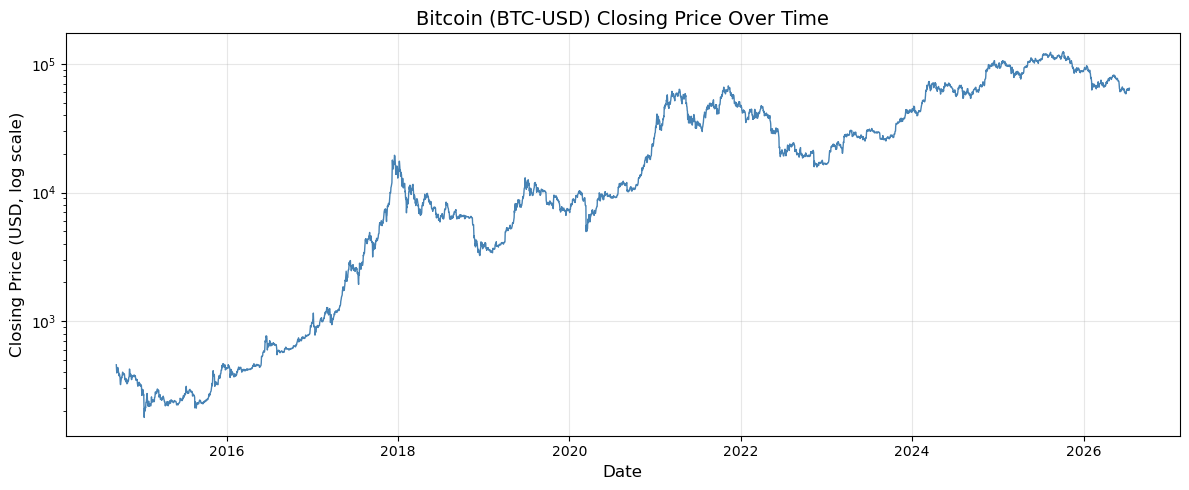

In [31]:
# The chart shows Bitcoin's closing price over time on a log scale

plt.figure(figsize=(12, 5))

plt.plot(df['date'], df['close'], color='steelblue', linewidth=1)

plt.yscale('log') 
plt.title('Bitcoin (BTC-USD) Closing Price Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (USD, log scale)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

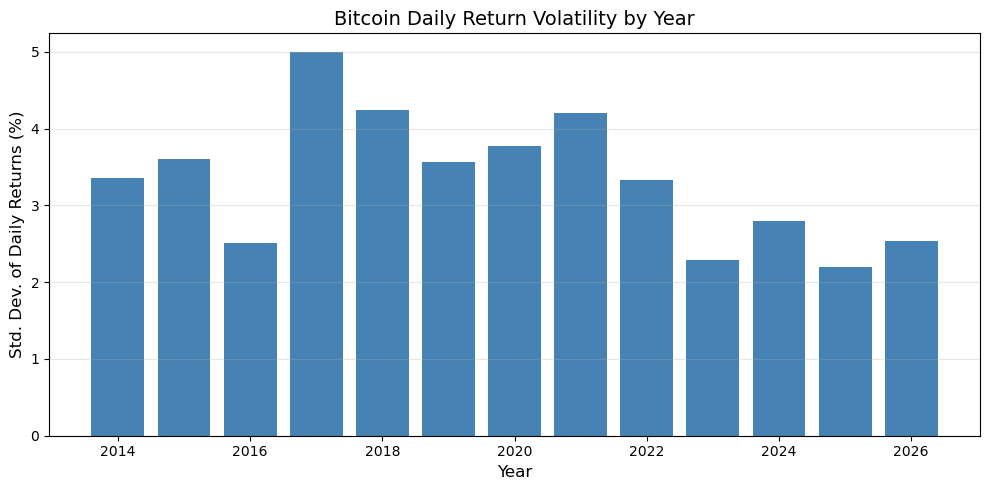

In [32]:
# Chart of yearly volatility

plt.figure(figsize=(10, 5))

plt.bar(yearly_stats.index, yearly_stats['volatility_pct'], color='steelblue')

plt.title('Bitcoin Daily Return Volatility by Year', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Std. Dev. of Daily Returns (%)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y') 
plt.tight_layout()
plt.show()

In [33]:
# We identify the bull and bear years by comparing the first and last price of each year

prices_first = df.groupby('year')['close'].first() 
prices_last = df.groupby('year')['close'].last()   

yearly_return = ((prices_last - prices_first) / prices_first * 100).round(2)
print('Bitcoin yearly percentage change in price:')
yearly_return

Bitcoin yearly percentage change in price:


year
2014     -29.99
2015      37.01
2016     121.89
2017    1318.02
2018     -72.60
2019      87.16
2020     302.79
2021      57.64
2022     -65.30
2023     154.23
2024     111.53
2025      -7.32
2026     -26.99
Name: close, dtype: float64

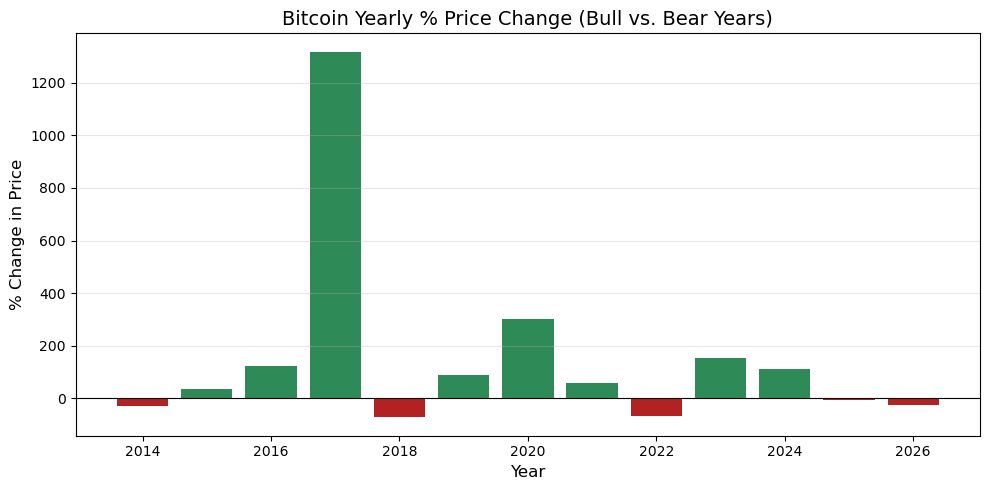

In [34]:
# Chart showing yearly price changes, colored green for bull years (positive) and red for bear years (negative)

colors = ['seagreen' if x >= 0 else 'firebrick' for x in yearly_return]

plt.figure(figsize=(10, 5))
plt.bar(yearly_return.index, yearly_return.values, color=colors)
plt.title('Bitcoin Yearly % Price Change (Bull vs. Bear Years)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('% Change in Price', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8) # zero line so it's obvious which years were up or down
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Comparing Bitcoin to the S&P 500

To see whether Bitcoin moves with the broader stock market (a sign of institutional adoption pulling it closer to a "risk-on" asset), we can pull the S&P 500 index the same way we pulled Bitcoin, merge the two datasets on date, and compare their daily returns.

In [35]:
# Here were pulling S&P 500 data the same way as Bitcoin, using its ticker symbol on Yahoo Finance

sp500 = yf.Ticker('^GSPC').history(period='max')
sp500 = sp500.reset_index()[['Date', 'Close']]
sp500.rename(columns={'Date': 'date', 'Close': 'sp500_close'}, inplace=True)
sp500['date'] = sp500['date'].dt.tz_localize(None)
sp500.head()

,date,sp500_close
0,1927-12-30,17.660000
1,1928-01-03,17.760000
2,1928-01-04,17.719999
3,1928-01-05,17.549999
4,1928-01-06,17.660000


In [36]:
merged = pd.merge(df[['date', 'close']], sp500, on='date', how='inner')

merged['btc_return'] = merged['close'].pct_change()
merged['sp500_return'] = merged['sp500_close'].pct_change()
merged = merged.dropna() 

correlation = merged['btc_return'].corr(merged['sp500_return'])
print(f'Correlation between BTC and S&P 500 daily returns: {correlation:.4f}')

Correlation between BTC and S&P 500 daily returns: 0.2260


## 3. Inference

**Question 1:** Does time (year) significantly predict Bitcoin's price?

**Regression:** We will use OLS linear regression, same as the final project's unemployment-vs-year model. Because Bitcoin's price grows exponentially rather than in a straight line, we regress the **log** of the closing price on year so the relationship is closer to linear:

log(close) = β0 + β1 × year + u

* β0 is the intercept
* β1 is the slope, roughly the average yearly growth rate in log terms
* u is the error term, other factors not included

If the p-value for year is less than 0.05, the relationship between year and Bitcoin's price is statistically significant.

In [37]:
df['log_close'] = np.log(df['close'])

y = df['log_close']
X = df[['year']]

X = sm.add_constant(X)
X.head()

,const,year
0,1.0,2014
1,1.0,2014
2,1.0,2014
3,1.0,2014
4,1.0,2014


In [38]:
est = sm.OLS(y, X)
est2 = est.fit()

print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:              log_close   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                 2.832e+04
Date:                Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:55:56   Log-Likelihood:                -4568.6
No. Observations:                4320   AIC:                             9141.
Df Residuals:                    4318   BIC:                             9154.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1040.0212      6.235   -166.817      0.0

In [39]:
beta0 = est2.params['const']
beta1 = est2.params['year']

print(f'The intercept (beta0) is {beta0:.4f}')
print(f'The slope (beta1) is {beta1:.4f}')
print(f'Fitted model: log(close) = {beta0:.2f} + {beta1:.4f} * year')

The intercept (beta0) is -1040.0212
The slope (beta1) is 0.5194
Fitted model: log(close) = -1040.02 + 0.5194 * year


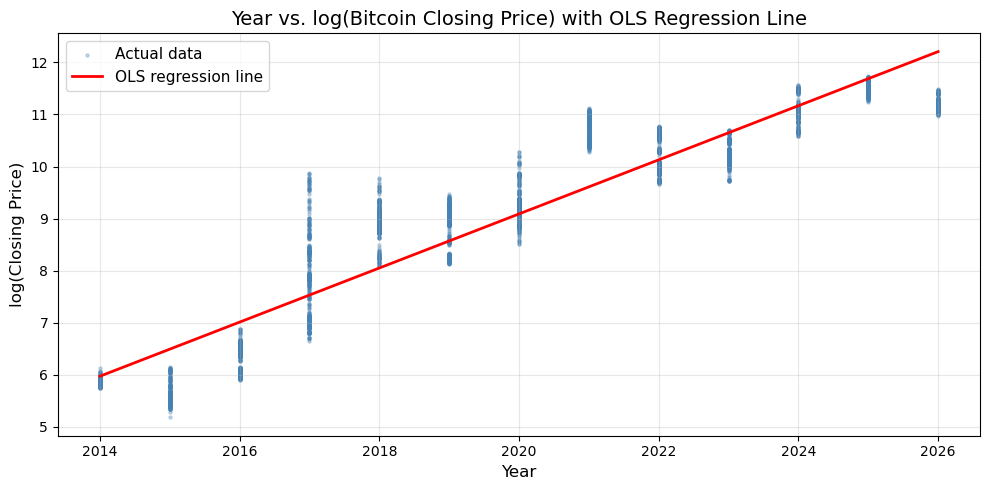

In [40]:
plt.figure(figsize=(10, 5))

plt.scatter(df['year'], df['log_close'], alpha=0.3, s=5,
            color='steelblue', label='Actual data')

fit_values = beta0 + beta1 * df['year']

plt.plot(df['year'], fit_values, color='red', linewidth=2, label='OLS regression line')

plt.title('Year vs. log(Bitcoin Closing Price) with OLS Regression Line', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('log(Closing Price)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Question 2:** Does the S&P 500's daily return significantly predict Bitcoin's daily return?

**Regression:** Using the merged daily returns from the section above:

btc_return = β0 + β1 × sp500_return + u

Here β1 works like a "market beta" for Bitcoin: how much Bitcoin tends to move on days the S&P 500 moves. A β1 near 0 would suggest Bitcoin moves independently of the stock market, while a larger, statistically significant β1 would suggest it behaves more like a "risk-on" asset that rises and falls with stocks.

In [41]:
y2 = merged['btc_return']
X2 = merged[['sp500_return']]

X2 = sm.add_constant(X2)

est3 = sm.OLS(y2, X2)
est4 = est3.fit()

print(est4.summary())

                            OLS Regression Results                            
Dep. Variable:             btc_return   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     159.8
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           1.02e-35
Time:                        17:55:57   Log-Likelihood:                 5311.3
No. Observations:                2972   AIC:                        -1.062e+04
Df Residuals:                    2970   BIC:                        -1.061e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0021      0.001      2.831   

In [42]:
beta0_mkt = est4.params['const']
beta1_mkt = est4.params['sp500_return']

print(f'The intercept (beta0) is {beta0_mkt:.6f}')
print(f'The "crypto beta" (beta1) is {beta1_mkt:.4f}')
print(f'Fitted model: btc_return = {beta0_mkt:.6f} + {beta1_mkt:.4f} * sp500_return')

The intercept (beta0) is 0.002107
The "crypto beta" (beta1) is 0.8452
Fitted model: btc_return = 0.002107 + 0.8452 * sp500_return


# 4. In Conclusion

This project used daily Bitcoin (BTC-USD) price data from Yahoo Finance, going back to 2014, to study how its price and volatility have evolved and how closely it tracks the broader stock market. The summary statistics and the yearly bull and bear breakdown showed that Bitcoin has gone through boom and bust cycles rather than moving steadily upward, with a few years posting triple digit percentage gains followed by years with losses of 60-70%. The volatility chart confirmed that Bitcoin's daily price swings have generally been much larger than what you'd expect from a traditional stock index, though volatility has trended somewhat lower in more recent years as the market has matured and more institutional investors have entered.

The first OLS regression of log(closing price) on year showed a positive and statistically significant relationship (p-value below 0.05), which lines up with Bitcoin's long-term upward trajectory since 2014, even though that growth has been anything but a straight line. The second regression, of Bitcoin's daily returns on the S&P 500's daily returns, found a positive and statistically significant coefficient, suggesting Bitcoin has at least some tendency to move in the same direction as the stock market on a given day. That relationship is a useful reminder that even though Bitcoin is often described as an alternative to traditional finance, macroeconomic conditions and broader investor sentiment still appear to influence its price.